# 📊 01 — Analisi Esplorativa degli Aiuti di Stato

Questo notebook esplora i dataset OpenData degli aiuti di stato italiani (2014–2025), classificati come **AI** o **NON_AI** in base alla correlazione con l'intelligenza artificiale.

**Obiettivi:**
1. Profiling dei dati: dimensioni, colonne, tipi
2. Distribuzione AI vs NON_AI per anno
3. Analisi della confidenza della classificazione
4. Confronto degli importi tra AI e NON_AI
5. Top beneficiari e misure associate all'AI
6. Copertura geografica (distribuzione regionale)

## 1. Setup e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Stile grafici
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
YEARS = list(range(2014, 2026))

# Colonne di interesse (per ridurre la memoria)
COLS_TO_LOAD = [
    'TITOLO_MISURA', 'DES_TIPO_MISURA', 'TITOLO_PROGETTO',
    'DATA_CONCESSIONE', 'DENOMINAZIONE_BENEFICIARIO', 'OBIETTIVO',
    'DES_TIPO_BENEFICIARIO', 'REGIONE_BENEFICIARIO',
    'IMPORTO_NOMINALE_TOTALE', 'ELEMENTO_DI_AIUTO_TOTALE',
    'SETTORI_ATTIVITA', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA'
]

print('Setup completato ✓')

Setup completato ✓


In [2]:
def load_year_chunked(year, chunksize=100_000):
    """Carica un file CSV anno per anno con chunk per gestire la memoria."""
    filepath = DATA_DIR / f'classified_aiuti_{year}.csv'
    if not filepath.exists():
        print(f'  ⚠ File non trovato: {filepath.name}')
        return pd.DataFrame()
    
    chunks = []
    for chunk in pd.read_csv(filepath, usecols=COLS_TO_LOAD, chunksize=chunksize, low_memory=False):
        chunks.append(chunk)
    
    df = pd.concat(chunks, ignore_index=True)
    df['ANNO'] = year
    return df

In [3]:
# Caricamento di tutti gli anni
# NOTA: se la memoria è limitata, caricare un anno alla volta
frames = []
for year in YEARS:
    print(f'Caricamento {year}...', end=' ')
    df_year = load_year_chunked(year)
    if not df_year.empty:
        print(f'{len(df_year):>12,} righe')
        frames.append(df_year)

df = pd.concat(frames, ignore_index=True)
del frames  # libera memoria

print(f'\n✅ Totale: {len(df):,} righe caricate')

Caricamento 2014...       15,448 righe
Caricamento 2015...        2,299 righe
Caricamento 2016...        8,378 righe
Caricamento 2017...      214,546 righe
Caricamento 2018...      685,622 righe
Caricamento 2019...      514,265 righe
Caricamento 2020...    2,669,916 righe
Caricamento 2021...    3,221,074 righe
Caricamento 2022...    2,062,853 righe
Caricamento 2023...    6,478,711 righe
Caricamento 2024...    6,022,284 righe
Caricamento 2025...    2,061,972 righe

✅ Totale: 23,957,368 righe caricate


## 2. Profiling dei Dati

In [4]:
# Panoramica delle colonne
print('=== INFO DATASET ===')
print(f'Righe totali:   {len(df):>12,}')
print(f'Colonne:        {len(df.columns):>12}')
print(f'Memoria (MB):   {df.memory_usage(deep=True).sum() / 1e6:>12,.1f}')
print()

# Tipi e valori mancanti
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Non-Null': df.notna().sum(),
    'Null (%)': (df.isna().sum() / len(df) * 100).round(2),
    'Unici': df.nunique()
})
info_df

=== INFO DATASET ===
Righe totali:     23,957,368
Colonne:                  14
Memoria (MB):       21,596.7



,Tipo,Non-Null,Null (%),Unici
TITOLO_MISURA,str,23957368,0.0,13643
DES_TIPO_MISURA,str,23957368,0.0,2
TITOLO_PROGETTO,str,23957357,0.0,991084
DATA_CONCESSIONE,str,23957368,0.0,3568
DENOMINAZIONE_BENEFICIARIO,str,23957368,0.0,5339934
DES_TIPO_BENEFICIARIO,str,23957368,0.0,4
REGIONE_BENEFICIARIO,str,23957368,0.0,563
IMPORTO_NOMINALE_TOTALE,float64,23957368,0.0,1851776
ELEMENTO_DI_AIUTO_TOTALE,float64,23957368,0.0,1905499
SETTORI_ATTIVITA,str,23694392,1.1,8768


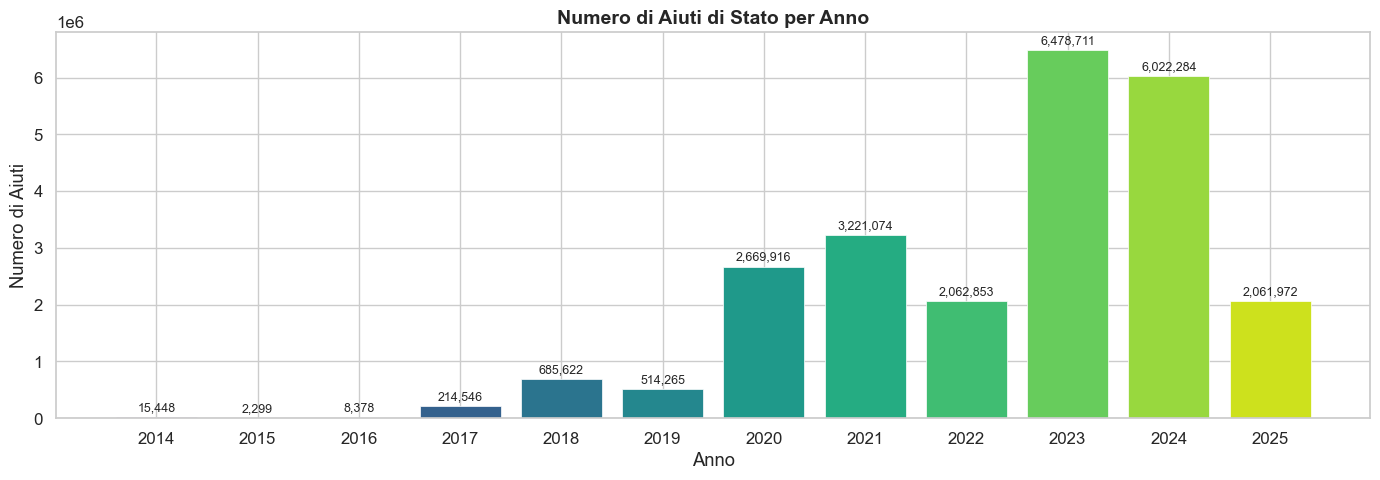

In [5]:
# Conteggio righe per anno
rows_per_year = df.groupby('ANNO').size().reset_index(name='num_righe')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(rows_per_year['ANNO'], rows_per_year['num_righe'], 
              color=sns.color_palette('viridis', len(rows_per_year)), edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, rows_per_year['num_righe']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rows_per_year['num_righe'])*0.01,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Anno')
ax.set_ylabel('Numero di Aiuti')
ax.set_title('Numero di Aiuti di Stato per Anno', fontsize=14, fontweight='bold')
ax.set_xticks(rows_per_year['ANNO'])
plt.tight_layout()
plt.show()

## 3. Distribuzione AI vs NON_AI per Anno

In [6]:
# Conteggio AI vs NON_AI per anno
class_counts = df.groupby(['ANNO', 'CLASSIFICAZIONE']).size().unstack(fill_value=0)

# Tabella riepilogativa
summary = class_counts.copy()
summary['TOTALE'] = summary.sum(axis=1)
if 'AI' in summary.columns:
    summary['% AI'] = (summary['AI'] / summary['TOTALE'] * 100).round(3)
summary

CLASSIFICAZIONE,AI,NON_AI,UNKNOWN,TOTALE,% AI
ANNO,,,,,
2014,0,15448,0,15448,0.000
2015,1,2298,0,2299,0.043
2016,6,8372,0,8378,0.072
2017,76,214470,0,214546,0.035
2018,1102,684519,1,685622,0.161
2019,451,513813,1,514265,0.088
2020,685,2669231,0,2669916,0.026
2021,405,3220669,0,3221074,0.013
2022,453,2062400,0,2062853,0.022


### 3.1 Esempi di righe classificate come UNKNOWN
Dato che il modello utilizzato è un classificatore semantico binario (AI vs NON_AI), gli `UNKNOWN` rappresentano anomale della pipeline. Di seguito alcuni esempi presi dal dataset.

In [7]:
unknown_df = df[df['CLASSIFICAZIONE'] == 'UNKNOWN']
print(f"Totale record UNKNOWN: {len(unknown_df):,}")
display(unknown_df.head(10))

Totale record UNKNOWN: 4


,TITOLO_MISURA,DES_TIPO_MISURA,TITOLO_PROGETTO,DATA_CONCESSIONE,DENOMINAZIONE_BENEFICIARIO,DES_TIPO_BENEFICIARIO,REGIONE_BENEFICIARIO,IMPORTO_NOMINALE_TOTALE,ELEMENTO_DI_AIUTO_TOTALE,SETTORI_ATTIVITA,OBIETTIVO,CLASSIFICAZIONE,CLASSIFICAZIONE_CONFIDENZA,ANNO
926292,POR-FESR Lazio 2014-2020 Obiettivo investiment...,Regime di aiuti,Sistema di valorizzazione Turistica della Reg...,2018-12-13+01:00,VALICA SRL,PMI,Lazio,240000.00,96000.00,J.62.0,PMI,UNKNOWN,0.0,2018
1440557,Intervento agevolativo in favore delle imprese...,Regime di aiuti,AGEVOLAZIONI ALLE IMPRESE PER FAVORIRE LA REGI...,2019-10-23+02:00,ALFREDO SALVATORI S.R.L.,PMI,Toscana,4586.95,4586.95,C.33.2,PMI,UNKNOWN,0.0,2019
17457317,PR FESR Liguria 2021 -2027. Interventi di sost...,Regime di aiuti,CCL,2024-10-04,ROMAGGI GIOVANNI & C. SNC,PMI,Liguria,57600.00,3174.22,G.46.3,Sviluppo settoriale,UNKNOWN,0.0,2024
18216616,Regime quadro nazionale sugli aiuti di Stato –...,Regime di aiuti,GIS-IMI 2021 COVID,2024-03-14,MANGER DES ...,PMI,Provincia Autonoma di Bolzano/Bozen,257.67,257.67,(NACE 2) A.01.4,Rimedio a un grave turbamento dell'economia,UNKNOWN,0.0,2024


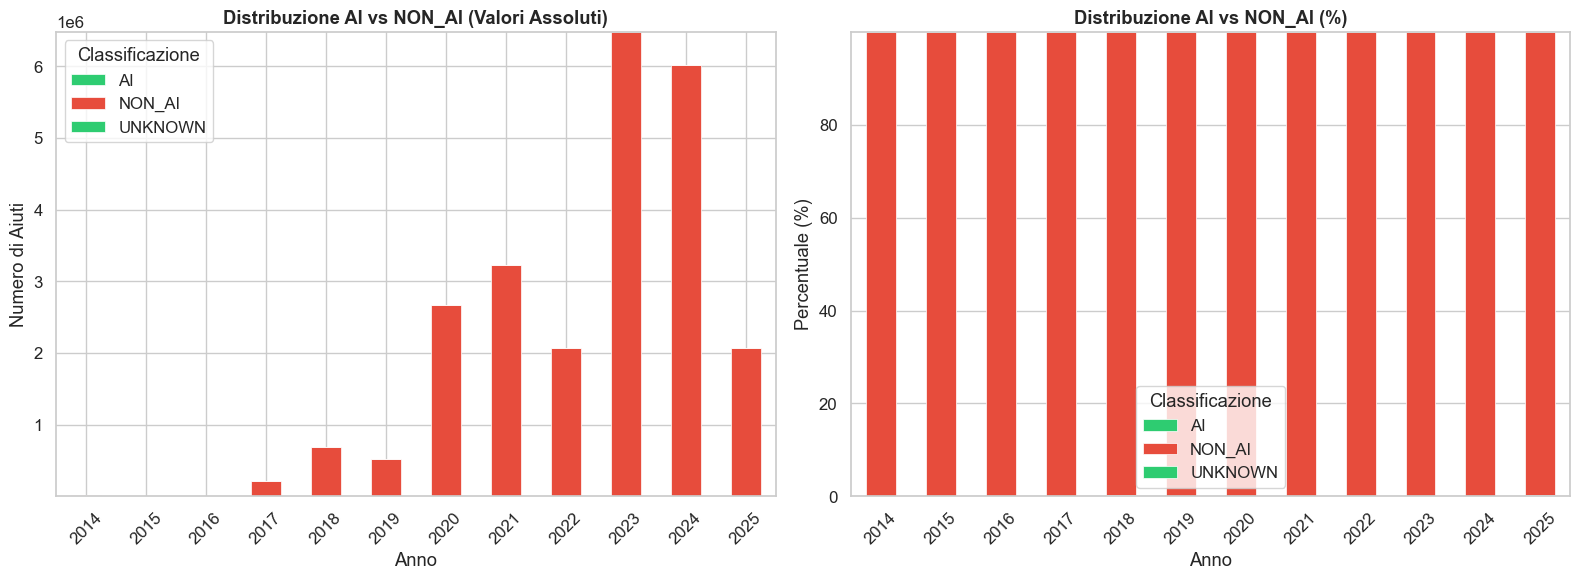

In [8]:
# Grafico a barre stacked
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valori assoluti
class_counts.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['#2ecc71', '#e74c3c'] if 'AI' in class_counts.columns else None,
                  edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribuzione AI vs NON_AI (Valori Assoluti)', fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Numero di Aiuti')
axes[0].legend(title='Classificazione')
axes[0].tick_params(axis='x', rotation=45)

# Percentuali
class_pct = class_counts.div(class_counts.sum(axis=1), axis=0) * 100
class_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#2ecc71', '#e74c3c'] if 'AI' in class_pct.columns else None,
               edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribuzione AI vs NON_AI (%)', fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('Percentuale (%)')
axes[1].legend(title='Classificazione')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Analisi della Confidenza della Classificazione

In [9]:
# Statistiche descrittive sulla confidenza
conf_stats = df.groupby('CLASSIFICAZIONE')['CLASSIFICAZIONE_CONFIDENZA'].describe().round(4)
conf_stats

,count,mean,std,min,25%,50%,75%,max
CLASSIFICAZIONE,,,,,,,,
AI,10826.0,0.9690,0.0809,0.5015,0.9844,0.9976,0.9990,0.9995
NON_AI,23946538.0,0.9995,0.0020,0.5020,0.9995,0.9995,0.9995,0.9995
UNKNOWN,4.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


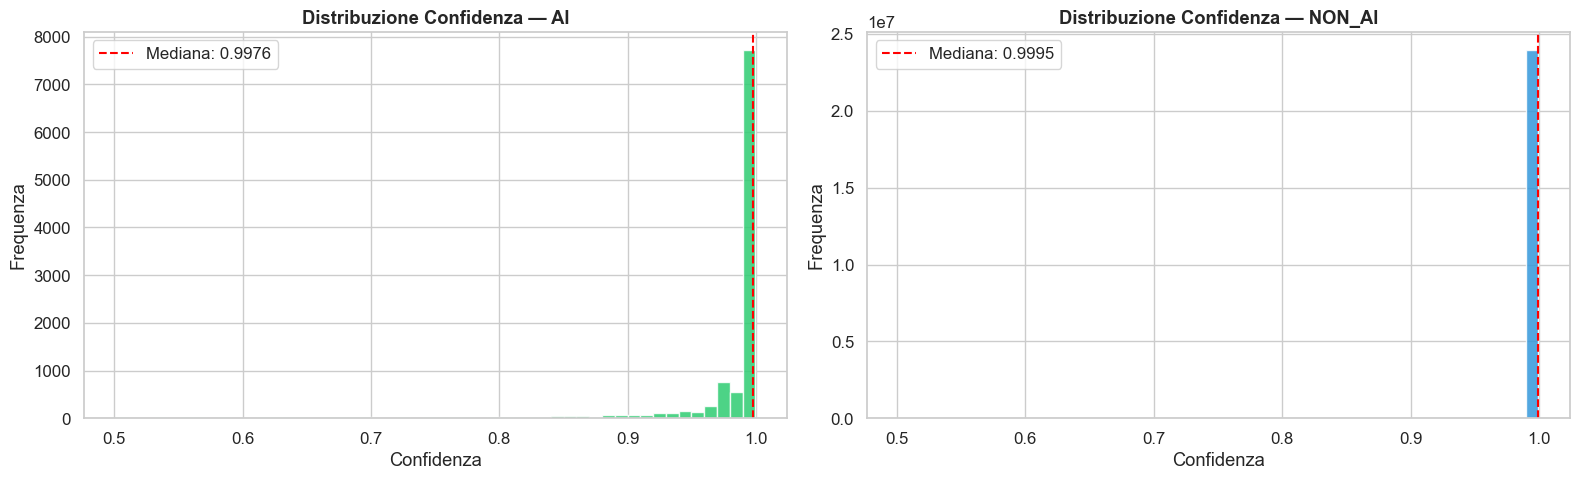

In [10]:
# Distribuzione della confidenza per AI e NON_AI
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, cls in enumerate(['AI', 'NON_AI']):
    subset = df[df['CLASSIFICAZIONE'] == cls]['CLASSIFICAZIONE_CONFIDENZA']
    color = '#2ecc71' if cls == 'AI' else '#3498db'
    
    axes[idx].hist(subset, bins=50, color=color, edgecolor='white', alpha=0.85)
    axes[idx].axvline(subset.median(), color='red', linestyle='--', linewidth=1.5, label=f'Mediana: {subset.median():.4f}')
    axes[idx].set_title(f'Distribuzione Confidenza — {cls}', fontweight='bold')
    axes[idx].set_xlabel('Confidenza')
    axes[idx].set_ylabel('Frequenza')
    axes[idx].legend()

plt.tight_layout()
plt.show()

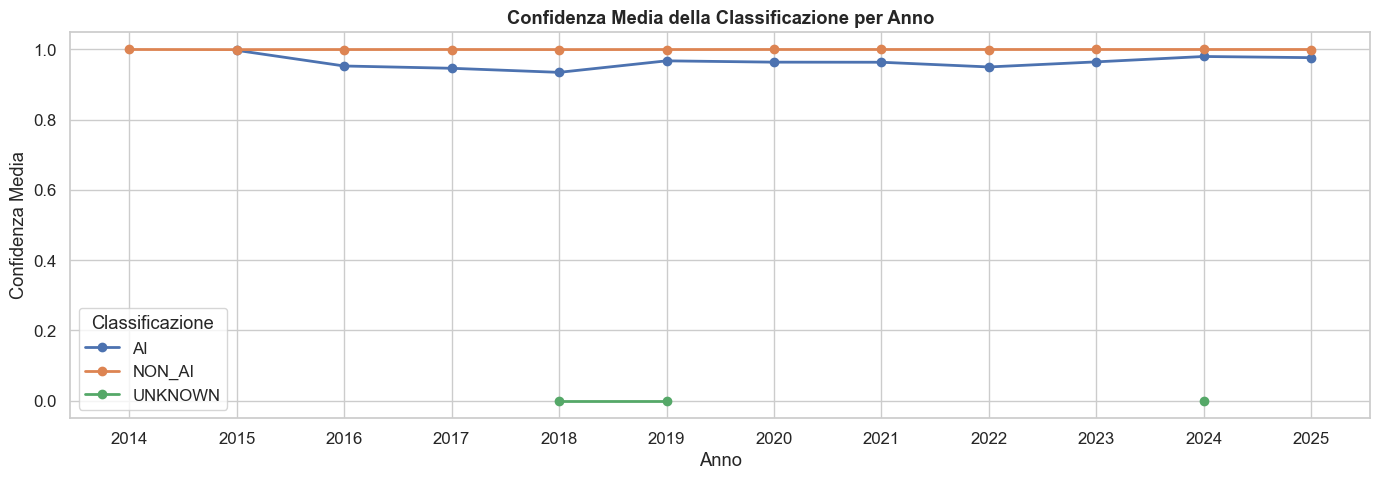

In [11]:
# Confidenza media per anno e classificazione
conf_by_year = df.groupby(['ANNO', 'CLASSIFICAZIONE'])['CLASSIFICAZIONE_CONFIDENZA'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
conf_by_year.plot(marker='o', ax=ax, linewidth=2)
ax.set_title('Confidenza Media della Classificazione per Anno', fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Confidenza Media')
ax.set_xticks(YEARS)
ax.legend(title='Classificazione')
plt.tight_layout()
plt.show()

## 5. Confronto Importi AI vs NON_AI

In [12]:
# Conversione importi a numerico
df['IMPORTO_NOMINALE_TOTALE'] = pd.to_numeric(df['IMPORTO_NOMINALE_TOTALE'], errors='coerce')
df['ELEMENTO_DI_AIUTO_TOTALE'] = pd.to_numeric(df['ELEMENTO_DI_AIUTO_TOTALE'], errors='coerce')

# Statistiche importi per classificazione
importi_stats = df.groupby('CLASSIFICAZIONE').agg(
    num_aiuti=('IMPORTO_NOMINALE_TOTALE', 'count'),
    importo_totale=('IMPORTO_NOMINALE_TOTALE', 'sum'),
    importo_medio=('IMPORTO_NOMINALE_TOTALE', 'mean'),
    importo_mediano=('IMPORTO_NOMINALE_TOTALE', 'median'),
    elemento_aiuto_totale=('ELEMENTO_DI_AIUTO_TOTALE', 'sum'),
    elemento_aiuto_medio=('ELEMENTO_DI_AIUTO_TOTALE', 'mean')
).round(2)

# Formattazione
for col in ['importo_totale', 'importo_medio', 'importo_mediano', 'elemento_aiuto_totale', 'elemento_aiuto_medio']:
    importi_stats[col] = importi_stats[col].apply(lambda x: f'€ {x:,.2f}')

importi_stats

,num_aiuti,importo_totale,importo_medio,importo_mediano,elemento_aiuto_totale,elemento_aiuto_medio
CLASSIFICAZIONE,,,,,,
AI,10826,"€ 1,578,866,406.90","€ 145,840.24","€ 23,685.00","€ 1,182,583,298.96","€ 109,235.48"
NON_AI,23946538,"€ 703,703,756,190.35","€ 29,386.45","€ 2,000.00","€ 502,684,089,137.61","€ 20,991.93"
UNKNOWN,4,"€ 302,444.62","€ 75,611.16","€ 31,093.48","€ 104,018.84","€ 26,004.71"


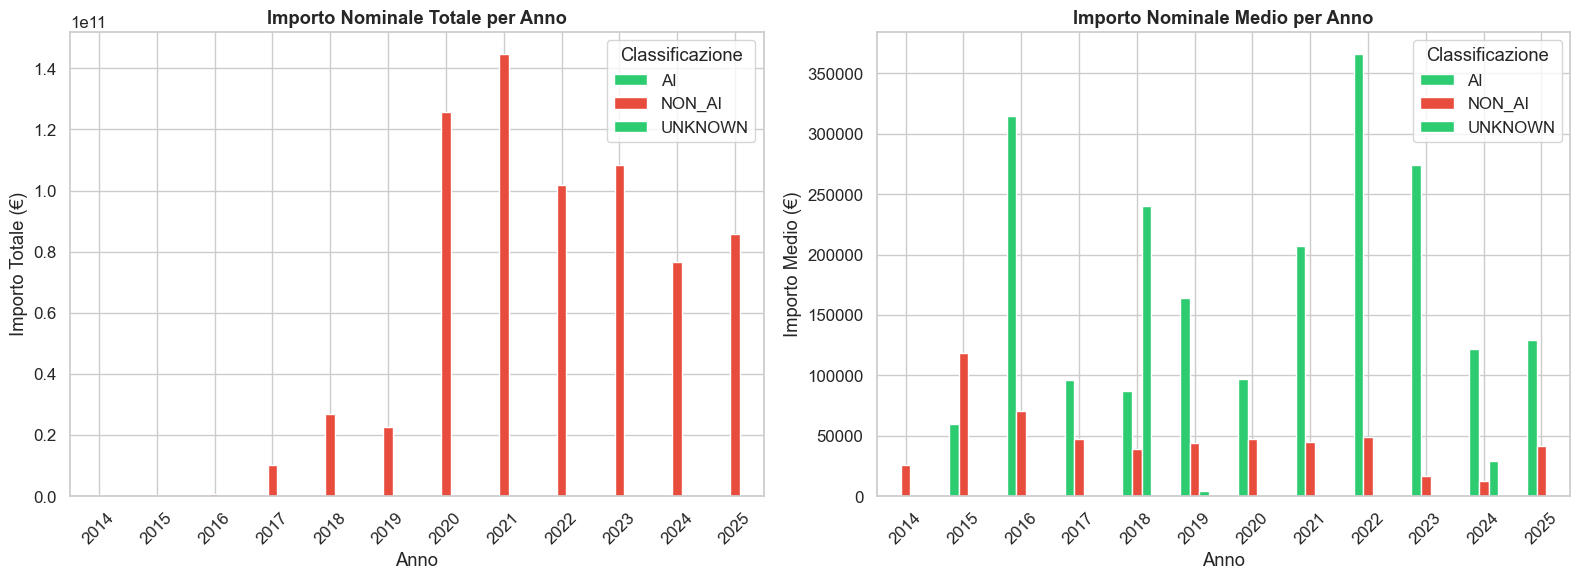

In [13]:
# Importo totale per anno e classificazione
importi_anno = df.groupby(['ANNO', 'CLASSIFICAZIONE'])['IMPORTO_NOMINALE_TOTALE'].agg(['sum', 'mean']).unstack()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Importo totale
importi_anno['sum'].plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Importo Nominale Totale per Anno', fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Importo Totale (€)')
axes[0].legend(title='Classificazione')
axes[0].tick_params(axis='x', rotation=45)

# Importo medio
importi_anno['mean'].plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Importo Nominale Medio per Anno', fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('Importo Medio (€)')
axes[1].legend(title='Classificazione')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Top Beneficiari e Misure AI

In [14]:
# Filtra solo aiuti AI
df_ai = df[df['CLASSIFICAZIONE'] == 'AI'].copy()
print(f'Aiuti classificati AI: {len(df_ai):,} ({len(df_ai)/len(df)*100:.3f}% del totale)')

Aiuti classificati AI: 10,826 (0.045% del totale)


In [15]:
# Top 20 beneficiari per numero di aiuti AI
top_beneficiari = (df_ai.groupby('DENOMINAZIONE_BENEFICIARIO')
                   .agg(num_aiuti=('CLASSIFICAZIONE', 'count'),
                        importo_totale=('IMPORTO_NOMINALE_TOTALE', 'sum'))
                   .sort_values('num_aiuti', ascending=False)
                   .head(20))

top_beneficiari['importo_totale'] = top_beneficiari['importo_totale'].apply(lambda x: f'€ {x:,.2f}')
top_beneficiari

,num_aiuti,importo_totale
DENOMINAZIONE_BENEFICIARIO,,
UNIVERSITA' DEGLI STUDI DI GENOVA,15,"€ 916,429.02"
CONSIGLIO NAZIONALE DELLE RICERCHE,13,"€ 6,961,791.70"
CRPA Soc. Cons. p. A.,9,"€ 19,999.32"
BEANTECH S.R.L.,9,"€ 2,663,802.31"
MARPOSS SOCIETA' PER AZIONI,8,"€ 193,710.10"
NEXTAGE S.R.L.,8,"€ 531,478.36"
MYWAI S.R.L.,8,"€ 1,819,917.80"
SACMI COOPERATIVA MECCANICI IMOLA SOCIETA' COOPERATIVA IN BREVE SACMI IMOLA S.C.,8,"€ 266,724.66"
AITEK SOCIETA' PER AZIONI,8,"€ 1,960,470.77"


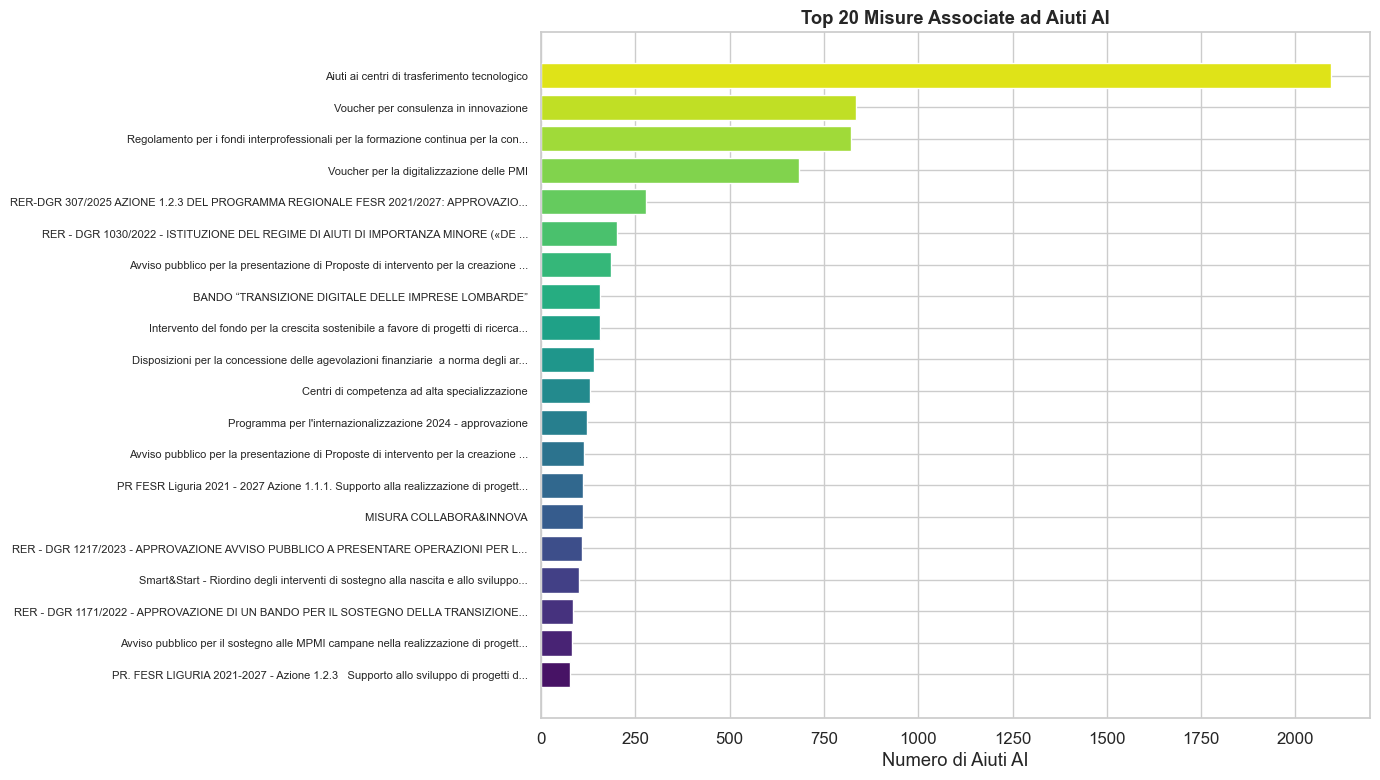

In [16]:
# Top 20 misure associate all'AI
top_misure = (df_ai.groupby('TITOLO_MISURA')
              .agg(num_aiuti=('CLASSIFICAZIONE', 'count'),
                   importo_totale=('IMPORTO_NOMINALE_TOTALE', 'sum'))
              .sort_values('num_aiuti', ascending=False)
              .head(20))

fig, ax = plt.subplots(figsize=(14, 8))
top_misure_plot = top_misure.sort_values('num_aiuti', ascending=True)
ax.barh(range(len(top_misure_plot)), top_misure_plot['num_aiuti'], 
        color=sns.color_palette('viridis', len(top_misure_plot)), edgecolor='white')
ax.set_yticks(range(len(top_misure_plot)))
ax.set_yticklabels([t[:80] + '...' if len(t) > 80 else t for t in top_misure_plot.index], fontsize=8)
ax.set_xlabel('Numero di Aiuti AI')
ax.set_title('Top 20 Misure Associate ad Aiuti AI', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Distribuzione Geografica

In [17]:
# Distribuzione regionale di AI vs NON_AI
regione_class = df.groupby(['REGIONE_BENEFICIARIO', 'CLASSIFICAZIONE']).size().unstack(fill_value=0)

if 'AI' in regione_class.columns:
    regione_class['% AI'] = (regione_class['AI'] / regione_class.sum(axis=1) * 100).round(3)
    regione_class = regione_class.sort_values('% AI', ascending=False)

regione_class

CLASSIFICAZIONE,AI,NON_AI,UNKNOWN,% AI
REGIONE_BENEFICIARIO,,,,
Campania Lombardia Provincia Autonoma di Bolzano/Bozen,1,0,0,100.0
Abruzzo Campania Emilia-Romagna Friuli-Venezia Giulia Lazio Liguria Lombardia Piemonte Provincia Autonoma di Trento Puglia Sicilia Toscana Veneto,1,0,0,100.0
Basilicata Campania Lazio Liguria Sicilia,1,0,0,100.0
Emilia-Romagna Lazio Lombardia Piemonte Toscana,1,0,0,100.0
Calabria Campania Puglia,1,0,0,100.0
...,...,...,...,...
Campania Lazio Puglia Sicilia Toscana,0,1,0,0.0
Campania Lazio Piemonte Puglia,0,1,0,0.0
Campania Lazio Lombardia Provincia Autonoma di Trento Veneto,0,8,0,0.0


## 8. Riepilogo

In questo notebook abbiamo esplorato:
- La **dimensione** e la **struttura** del dataset
- La **distribuzione** AI vs NON_AI e la sua evoluzione temporale
- La **confidenza** della classificazione
- Gli **importi** degli aiuti confrontati tra AI e NON_AI
- I **top beneficiari** e le **misure** più associate all'AI
- La **distribuzione regionale** degli aiuti AI

Per approfondimenti quantitativi → **02_analisi_quantitativa.ipynb**  
Per analisi qualitative e testuali → **03_analisi_qualitativa.ipynb**